Dataset: California Housing que viene integrado en sklearn. El objetivo es predecir un valor continuo (el precio de la vivienda).

https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html


# Ejercicio: Predicción de Precios de Vivienda

**Contexto:** Trabajáis para una consultora inmobiliaria en California. Se os ha entregado un dataset con información socioeconómica de diferentes distritos y vuestro objetivo es construir un modelo capaz de predecir el valor medio de la vivienda.

**El Dataset:** Utilizaremos el dataset `fetch_california_housing` de Scikit-Learn.

### Tareas a realizar:

1.  **Carga de datos:** Importa el dataset y sepáralo en variables predictoras (`X`) y variable objetivo (`y`).
2.  **División del dataset:** Divide los datos en conjuntos de **Entrenamiento (80%)** y **Test (20%)**. No olvides fijar un `random_state` para que tus resultados sean reproducibles.
3.  **Análisis de Dimensionalidad (PCA):** * Aplica un PCA para reducir las 8 variables originales a **3 componentes principales**.
    * ¿Cuánta varianza explicada acumulada tienen esos 3 componentes?
    * Visualiza en un gráfico 3D las 3 componentes
4.  **Escalado de Datos:** Aplica `StandardScaler` a tus datos de entrenamiento y test.
    * Visualiza en histogramas las nuevas variables de entrenamiento escaladas. 
6.  **Entrenamiento de Modelos (Comparativa):**
    * Entrena una **Regresión Lineal (OLS)** básica.
    * Entrena un **SGDRegressor** configurando una `tol` de 1e-3 y un `max_iter` de 1000.
    * Entrena un modelo con **Regularización Lasso** (prueba con un `alpha=0.1`). ¿Cuántos coeficientes se han ido a cero?
7.  **Evaluación:**
    * Calcula el **R² Ajustado**, el **MAE** y el **RMSE** para cada uno de los tres modelos utilizando el conjunto de **test**.
    * ¿Qué modelo generaliza mejor?
8.  **Persistencia:** Guarda el mejor modelo y el escalador utilizado en archivos `.pkl` usando la librería `joblib`.

In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

# Carga de datos
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print(f"Variables disponibles: {data.feature_names}")

X_frame = pd.DataFrame(X, columns=data.feature_names)
X_frame['Precio $'] = y * 100_000
X_frame.head()

Variables disponibles: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Precio $
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,452600.0
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,358500.0
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,352100.0
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,341300.0
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,342200.0


## 2. División del dataset ##

In [2]:
from sklearn.model_selection import train_test_split

# 2. División del dataset (80/20)
# Sklearn puede trabajar sobre DataFrames de Pandas (X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Registros Entrenamiento: {len(X_train)}")
print(f"Registros Test: {len(X_test)}")

Registros Entrenamiento: 16512
Registros Test: 4128


## 3. Análisis de la dimensionalidad (PCA) ##
Es más conveniente hacer el PCA después del escalado, lo repetiremos después.

Varianza explicada acumulada (3 comp): 1.0000


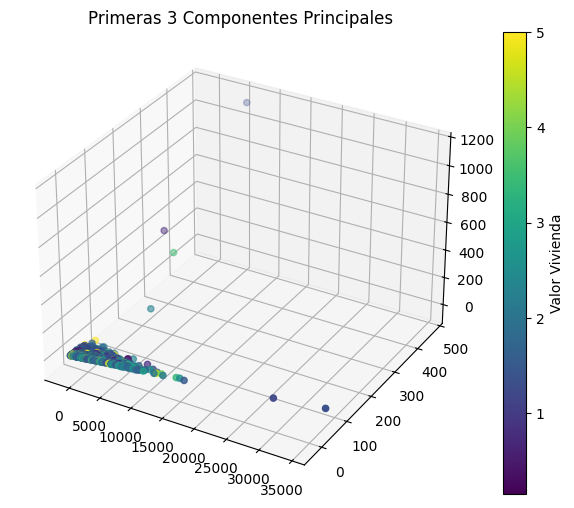

In [3]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# 3. PCA a 3 componentes
pca = PCA(n_components=3)
X_train_pca = pca.fit_transform(X_train)

var_acumulada = np.sum(pca.explained_variance_ratio_)
print(f"Varianza explicada acumulada (3 comp): {var_acumulada:.4f}")

# Visualización 3D
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], X_train_pca[:, 2], c=y_train, cmap='viridis')
ax.set_title("Primeras 3 Componentes Principales")
plt.colorbar(sc, label='Valor Vivienda')
plt.show()

## 4. Escalado de datos. ##

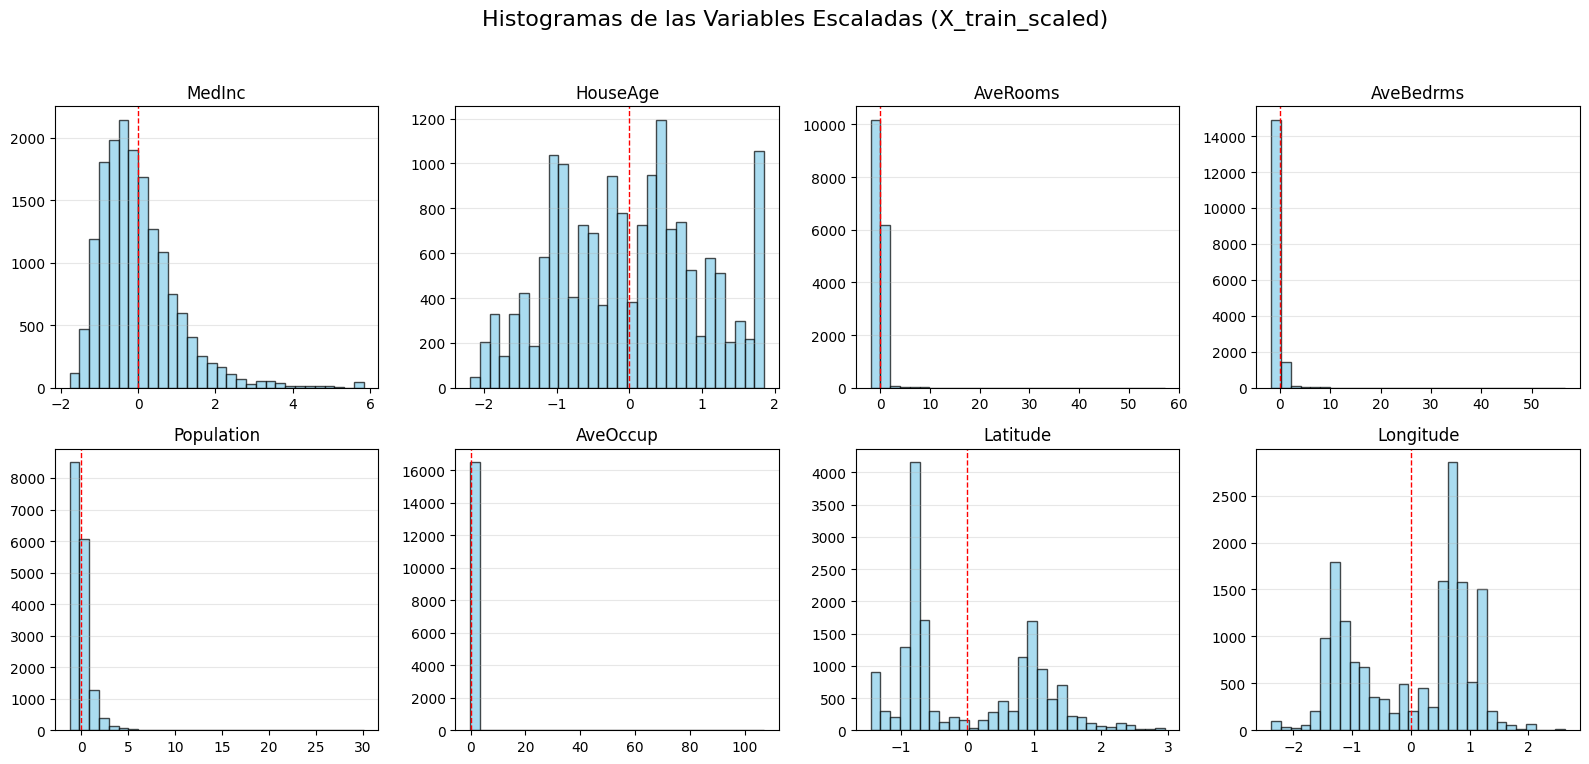

In [4]:
from sklearn.preprocessing import StandardScaler

# 4. Escalado
scaler = StandardScaler()
# Aplicamos el algoritmo a los datos de entrenamiento
X_train_scaled = scaler.fit_transform(X_train) # devuelve un ndarray de numpy
# Transformamos también los datos de test
X_test_scaled = scaler.transform(X_test)


# Configuramos la figura (2 filas, 4 columnas)
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 8))
fig.suptitle('Histogramas de las Variables Escaladas (X_train_scaled)', fontsize=16)

# Aplanamos el array de ejes para iterar fácilmente
axes = axes.flatten()

# Nombres de las columnas originales para los títulos
columnas = data.feature_names

# Pintamos los 8 histogramas con un for
for i in range(len(columnas)):
    # Histograma columna i
    axes[i].hist(X_train_scaled[:, i], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(columnas[i])
    axes[i].grid(axis='y', alpha=0.3)
    # Dibujamos una línea roja en el 0 para verificar el centrado
    axes[i].axvline(0, color='red', linestyle='dashed', linewidth=1)

# Ajustamos el diseño para que no se solapen los títulos
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

El StandarScaler transforma los datos para que la media sea 0 y la desviación estándar sea 1.

La mitad de los histogramas muestran correctamente esta transformación. Los otros no, pero no porque no se haya hecho correctamente, sino que es debido a valores demasiado altos (outliers) en los datos originales, provocando que haya algún valor muy alto aún escalado.

In [ ]:
# Vamos a comprobar los valores de AveOccup (columna 5)
print(f"Media AveOccup {round(X_train_scaled[:, 5].mean(), 2)} ")
print(f"Std AveOccup {round(X_train_scaled[:, 5].std(), 2)} ")
print(f"Valor máximo de AveOccup escalado {X_train_scaled[:, 5].max()}")
print(f"Valor máximo de AveOccup sin escalar {X_train[:, 5].max()}")

## Escalado con RobustScaler ##
Funciona de la siguiente manera:

1.Resta la Mediana (en lugar de la media).

1.Divide por el IQR (Rango entre el percentil 25 y 75).
    
Esto garantiza que el 50% central de los datos quede siempre en un rango muy similar, independientemente de lo lejos que estén los outliers.

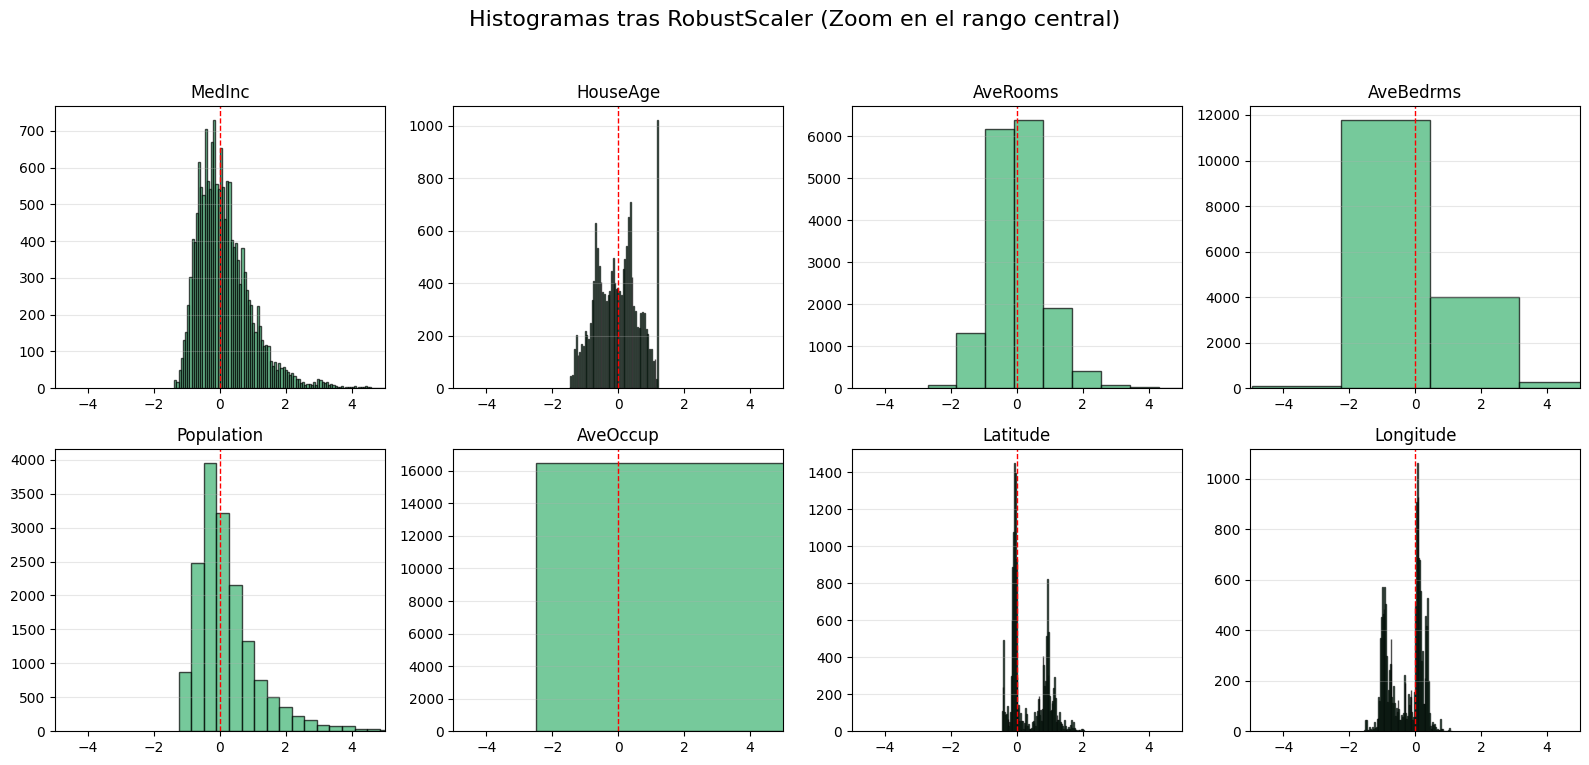

In [5]:
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt

# 1. Instanciar y aplicar RobustScaler
robust_scaler = RobustScaler()
X_train_robust = robust_scaler.fit_transform(X_train)
X_test_robust = robust_scaler.transform(X_test)

# 2. Configurar la visualización (2 filas, 4 columnas)
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 8))
fig.suptitle('Histogramas tras RobustScaler (Zoom en el rango central)', fontsize=16)

axes = axes.flatten()
columnas = X_frame.columns[:8]

for i in range(len(columnas)):
    # Graficamos el histograma
    axes[i].hist(X_train_robust[:, i], bins=100, color='mediumseagreen', edgecolor='black', alpha=0.7)
    axes[i].set_title(columnas[i])
    
    # IMPORTANTE: Hacemos "zoom" automático al rango donde está el 99% de los datos
    # para que los outliers no nos impidan ver la campana.
    axes[i].set_xlim(-5, 5) 
    
    axes[i].grid(axis='y', alpha=0.3)
    axes[i].axvline(0, color='red', linestyle='dashed', linewidth=1) # Línea en la Mediana

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 3bis. PCA post escalado ##

Varianza explicada acumulada (3 comp): 0.9890


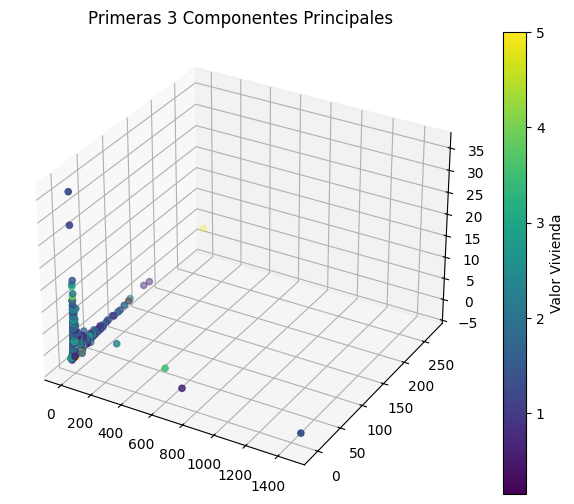

In [6]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# 3. PCA a 3 componentes
pca = PCA(n_components=3)
X_train_pca = pca.fit_transform(X_train_robust)

var_acumulada = np.sum(pca.explained_variance_ratio_)
print(f"Varianza explicada acumulada (3 comp): {var_acumulada:.4f}")

# Visualización 3D
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], X_train_pca[:, 2], c=y_train, cmap='viridis')
ax.set_title("Primeras 3 Componentes Principales")
# Volvemos a hacer "zoom" para evitar que los outliers nos impidan ver las diferencias
plt.colorbar(sc, label='Valor Vivienda')
plt.show()

## 5. Entrenamiento de Modelos (Comparativa)
* Entrena una Regresión Lineal (OLS) básica.
* Entrena un SGDRegressor configurando una tol de 1e-3 y un max_iter de 1000.
* Entrena un modelo con Regularización Lasso (prueba con un alpha=0.1).
 
¿Cuántos coeficientes se han ido a cero?

In [7]:
from sklearn.linear_model import LinearRegression, SGDRegressor, Lasso
import numpy as np

# 1. Regresión Lineal Básica (OLS)
ols_model = LinearRegression()
ols_model.fit(X_train_robust, y_train)

# 2. SGDRegressor 
# Usamos random_state para que el descenso de gradiente sea reproducible
sgd_model = SGDRegressor(tol=1e-3, max_iter=1000, random_state=42)
sgd_model.fit(X_train_robust, y_train)

# 3. Regresión Lasso (Regularización L1)
# Hiperparámetro alpha controla la simplicidad del modelo resultante
# VAlors de 0 a infinito. Cuanto más grande, más variables descartará (coeficientes a 0)
# Con alpha=0 se comporta como OLS
# Entre 0.001 - 0.01 penalización suave
# Entre 0.1 y 1 penalización media
# Se puede probar entre varios valores, comparando modelos resultantes
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train_robust, y_train)

# Cálculo de coeficientes eliminados por Lasso
num_coef_0 = np.sum(lasso_model.coef_ == 0)
# Averiguamos cuáles son las columnas con coeficientes a 0 con indexación booleana
variables_eliminadas = np.array(data.feature_names)[lasso_model.coef_ == 0]

print("--- Resultados del Entrenamiento ---")
print(f"OLS y SGD entrenados correctamente.")
print(f"Lasso ha enviado {num_coef_0} coeficientes a cero.")
if num_coef_0 > 0:
    print(f"Variables descartadas por Lasso: {variables_eliminadas}")

print("-"*20)
# Para que los arrays de Numpy no usen notación científica (suprimir notación 'e')
np.set_printoptions(suppress=True, precision=3)
print("--- Coeficientes de los modelos ---\n")
# Hacemos un DataFrame para mostrar los coeficientes de cada modelo de forma más estructurada
df_coefs = pd.DataFrame({
    'Nombre Variable': data.feature_names,
    'Coef_OLS': ols_model.coef_,
    'Coef_SGD': sgd_model.coef_,
    'Coef_Lasso': lasso_model.coef_
})
df_coefs

--- Resultados del Entrenamiento ---
OLS y SGD entrenados correctamente.
Lasso ha enviado 5 coeficientes a cero.
Variables descartadas por Lasso: ['AveRooms' 'AveBedrms' 'Population' 'Latitude' 'Longitude']
--------------------
--- Coeficientes de los modelos ---



,Nombre Variable,Coef_OLS,Coef_SGD,Coef_Lasso
0,MedInc,0.989990,2.931219e+09,0.799440
1,HouseAge,0.184761,-7.131804e+09,0.080909
2,AveRooms,-0.198425,-1.151466e+09,-0.000000
3,AveBedrms,0.073490,-2.328865e+09,-0.000000
4,Population,-0.001902,-1.711235e+10,-0.000000
5,AveOccup,-0.003002,-5.769494e+10,-0.002515
6,Latitude,-1.591014,1.121557e+09,-0.000000
7,Longitude,-1.648091,-6.678447e+09,-0.000000


Vemos coeficientes demasiado grandes en SGD. Es un problema derivado de tener outliers demasiado altos. Se puede corregir pero no entraremos en ello. Este modelo lo podemos descartar, como se verá en el siguiente punto al evaluarlo.

## 6.-Evaluacion ##
1. Calcula el R² Ajustado, el MAE y el RMSE para cada uno de los tres modelos utilizando el conjunto de test.

1. ¿Qué modelo generaliza mejor?

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Función auxiliar para calcular el r2 ajustado a partir de r2
def calcular_r2_ajustado(r2, n, p):
    """Calcula el R2 ajustado: n=muestras, p=variables"""
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

# Creamos una función que recibe un modelo y dataset de test (datos y objetivo)
# Retorna un diccionario con nombre del modelo y las 3 métricas
def calcular_metricas(nombre_modelo, modelo, X_test, y_test):
    # Usamos el modelo para precedir la variable objetivo
    y_pred = modelo.predict(X_test)

    # CÁLCULO DE MÉTRICAS
    # R2
    r2 = r2_score(y_test, y_pred)
    # R2 ajustado
    n = len(y_test) # Número de observaciones
    p = X_test.shape[1] # Número de variables
    r2_aj = calcular_r2_ajustado(r2, n, p)
    # MAE
    mae = mean_absolute_error(y_test, y_pred)
    # RMSE
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # Diccionario de retorno
    return {
        'Modelo': nombre_modelo,
        'R2_Ajustado': r2_aj,
        'MAE': mae,
        'RMSE': rmse
    }

# Evaluamos los 3 modelos entrenados anteriormente
res_ols = calcular_metricas("OLS (Lineal)", ols_model, X_test_robust, y_test)
res_sgd = calcular_metricas("SGD Regressor", sgd_model, X_test_robust, y_test)
res_lasso = calcular_metricas("Lasso (Alpha 0.1)", lasso_model, X_test_robust, y_test)

# Creamos el DataFrame comparativo
df_comparativa = pd.DataFrame([res_ols, res_sgd, res_lasso])

# Para que los DataFrames de Pandas muestren 3 decimales (0.575 en vez de 5.7e-01)
pd.options.display.float_format = '{:.3f}'.format

# Mostramos la tabla
df_comparativa

,Modelo,R2_Ajustado,MAE,RMSE
0,OLS (Lineal),0.575,0.533,0.746
1,SGD Regressor,-12164325672388910907392.000,47433760520.441,126132240719.735
2,Lasso (Alpha 0.1),0.467,0.632,0.835


Interpretaciones de métricas

* R2: Lo más alto posible (valor máximo es 1).
* MAE: Lo más bajo posible
* RMSE: Lo más bajo posible

# 📊 Evaluación y Comparativa de Modelos de Regresión

En esta fase del proyecto, hemos evaluado la capacidad de tres algoritmos diferentes para predecir el valor de las viviendas. Se han utilizado métricas clave como el **$R^2$ Ajustado**, el **MAE** (Error Absoluto Medio) y el **RMSE** (Raíz del Error Cuadrático Medio).

## 1. Tabla Comparativa de Resultados

| Modelo | $R^2$ Ajustado | MAE | RMSE | Estado |
| :--- | :---: | :---: | :---: | :--- |
| **OLS (Regresión Lineal)** | **0.575** | **0.533** | **0.746** | ✅ **Ganador** |
| **Lasso (Alpha 0.1)** | 0.467 | 0.632 | 0.835 | ⚠️ Subajustado |
| **SGD Regressor** | -1.216e+22 | 4.743e+10 | 1.261e+11 | ❌ Error Crítico |

---

## 2. Análisis de los Modelos

### 🥇 El Ganador: OLS (Lineal)
Es el modelo con mejor rendimiento. Al ser un cálculo analítico, no depende de una tasa de aprendizaje y encuentra el mejor ajuste matemático directo para una línea recta.
* **Capacidad Explicativa:** El modelo explica el **57.5%** de la variación de los precios.
* **Error Promedio:** Las predicciones fallan, en promedio, por unos **$53,320**.
* **Sensibilidad a Outliers:** El RMSE (0.746) es mayor al MAE, lo que indica que el modelo comete errores más grandes en ciertos distritos específicos.

### ❌ El Desastre: SGD Regressor (Explosión del Gradiente)
Este modelo falló catastróficamente debido a una mala calibración.
* **Veredicto:** El modelo es inútil en su estado actual. Un $R^2$ negativo de tal magnitud indica que las predicciones están totalmente fuera de rango.
* **Causa:** El algoritmo "rebotó" hacia el infinito. Al encontrar valores extremos, el paso de aprendizaje fue demasiado grande y el modelo se desestabilizó.

### ⚠️ El "Tímido": Lasso (Alpha 0.1)
Lasso aplica una penalización para simplificar el modelo, pero en este caso fue contraproducente.
* **Problema:** Sufre de **Underfitting** (subajuste).
* **Causa:** El parámetro `alpha=0.1` es demasiado estricto. El modelo eliminó variables importantes, volviéndose "demasiado simple" para capturar la realidad de los datos.

---

## 3. Diagnóstico del Gráfico de Residuos (Análisis de Error)

Al analizar la distribución de los errores del modelo ganador (**OLS**), observamos dos fenómenos importantes:

1.  **Homocedasticidad:** En la zona central, los errores se distribuyen de forma aleatoria, lo que valida el uso de un modelo lineal para la mayoría de los casos.
2.  **Sesgo por Truncamiento:** Se observa una línea diagonal clara. Esto se debe a que el dataset original está **censurado a $500,000**. Como el modelo predice

## 7.-Persistencia ##
Para poder usar nuestro modelo en una aplicación real sin tener que entrenarlo cada vez, utilizamos la librería joblib.

Es fundamental guardar tanto el modelo como el escalador, ya que cualquier dato nuevo debe sufrir la misma transformación que los datos de entrenamiento antes de hacer la predicción.

In [9]:
import joblib

# Guardamos el modelo ganador (OLS)
joblib.dump(ols_model, 'modelo_ols_v1.pkl')

# Guardamos el escalador robusto (¡Imprescindible!)
joblib.dump(robust_scaler, 'escalador_robusto.pkl')

print("Modelo y Escalador guardados correctamente en archivos .pkl")

Modelo y Escalador guardados correctamente en archivos .pkl


### Predicción: uso del modelo guardado ###


In [11]:
import pandas as pd
import joblib

# 1. Cargamos los archivos
modelo_cargado = joblib.load('modelo_ols_v1.pkl')
escalador_cargado = joblib.load('escalador_robusto.pkl')

# 2. Definimos los datos de una "nueva casa"
nueva_casa = [[8.32, 41.0, 6.98, 1.02, 322.0, 2.55, 37.88, -122.23]]

# --- ARREGLO AQUÍ ---
# Definimos los nombres de las columnas en el orden exacto del entrenamiento
columnas = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

# Convertimos la lista a un DataFrame de Pandas con sus nombres
nueva_casa_df = pd.DataFrame(nueva_casa, columns=columnas)

# 3. Escalar usando el DataFrame (ya no dará Warning)
nueva_casa_escalada = escalador_cargado.transform(nueva_casa_df)
# ---------------------

# 4. Realizar la predicción
prediccion = modelo_cargado.predict(nueva_casa_escalada)

print(f"Predicción del modelo: {prediccion[0]:.3f} -> ({prediccion[0]*100_000:,.0f}$)")

Predicción del modelo: 4.147 -> (414,715$)
